### [Detecting Stock Market Cycles](https://medium.com/@crisvelasquez/detecting-stock-market-cycles-a62b11231e24)

> Determining early, mid-late, decline, and recovery regimes using a composite of **FRED indicators** and **S&P 500** trends in Python.

---

Market cycles push asset prices through asset prices through phases of expansion, contraction, and uncertainty.

These regimes shape both risk and return. But cycles don't announce themselves in real time, and the volatility doesn't move in isolation.

The challenge is that market shifts happen as growth, inflation, credit, and sentiment change on their own timing and signal-to-noise ratio.

---

Market cycles shape the environment for risk and return, which is critical for effective asset allocation.

Patterns in growth, inflation, credit, and sentiment drive asset prices, but each factor moves on its own schedule.

Cycle recognition allows investors to systematically tilt toward or away from risk, growth, or defensiveness, without relying on forecasts.

In [1]:
!pip install -qU pandas-datareader yfinance requests==2.32.4

In [2]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from datetime import datetime
import matplotlib.dates as mdates
import math
plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# PARAMETERS
START, END    = '2000-01-01', datetime.today().strftime('%Y-%m-%d')
FREQ          = 'ME'       # Pandas resample frequency for data (e.g. 'ME'=month‑end); controls aggregation period—higher freq ('D') adds noise, lower ('Q') smooths
SLOPE_WINDOW  = 3          # Look‑back periods for slope = comp.diff(SLOPE_WINDOW); larger values smooth and delay turn signals, smaller values speed detection but add volatility
SMOOTH_WINDOW = 2          # Window for composite moving average before plotting; larger windows yield a smoother but more lagged chart, smaller windows follow raw swings closely

##### **Retrieve Data Inputs**

Each indicator is retrieved from **FRED** using its public ticker.

In [3]:
# SERIES MAP
fred_map = {
    # growth / activity
    'LEI'               : 'USSLIND',           # Leading Index for US (Philly Fed state leading), proxy for overall LEI
    'Philly Manuf Diff' : 'GACDFSA066MSFRBPHI',# Philly Fed manufacturing diffusion index, proxy for ISM Mfg PMI (ISM is no longer supported at Fred)
    'Texas Serv Diff'   : 'TSSOSBACTUAMFRBDAL',# Dallas Fed services diffusion index, proxy for ISM Services PMI (ISM is no longer supported at Fred)
    'Capacity Util'     : 'CUMFNS',            # Industrial capacity utilization rate
    'BBK Leading'       : 'BBKMLEIX',          # Brave‑Butters‑Kelley leading index, leading growth component
    'CFNAI 3MMA'        : 'CFNAIMA3',          # Chicago Fed National Financial Activity Index 3‑mo avg

    # inflation sub‑block
    'Core CPI'          : 'CPILFESL',          # Core CPI ex‑food & energy, inflation proxy
    'Core PCE'          : 'PCEPILFE',          # Core PCE inflation proxy
    'Hourly Wage'       : 'CES0500000003',     # Avg hourly earnings YoY (BLS)
    'PPI'               : 'PPIACO',            # Producer Price Index commodities YoY
    'Commodities'       : 'PALLFNFINDEXM',     # BCOM commodity price index YoY

    # rates & credit
    '10Y'               : 'DGS10',             # 10‑year Treasury yield (Δ12m)
    'HY OAS'            : 'BAMLH0A0HYM2',      # High‑yield OAS (Δ12m, inverted)

    # stress proxy
    'StLouis FSI'       : 'STLFSI4',           # St. Louis Fed Financial Stress Index (inverted)
}

# FETCH & RESAMPLE
raw = {k: web.DataReader(tkr, 'fred', START, END).squeeze()
       for k, tkr in fred_map.items()}
df  = pd.DataFrame(raw).resample(FREQ).last().ffill()

df.head()

,LEI,Philly Manuf Diff,Texas Serv Diff,Capacity Util,BBK Leading,CFNAI 3MMA,Core CPI,Core PCE,Hourly Wage,PPI,Commodities,10Y,HY OAS,StLouis FSI
DATE,,,,,,,,,,,,,,
2000-01-31,1.61,11.2,NaN,80.7280,-0.078638,0.38,179.3,74.306,NaN,128.3,NaN,6.68,4.87,0.0539
2000-02-29,1.48,14.5,NaN,80.5879,-0.068595,0.19,179.4,74.415,NaN,129.8,NaN,6.42,5.08,0.2455
2000-03-31,1.88,19.4,NaN,80.7820,-0.224681,0.14,180.0,74.568,NaN,130.8,NaN,6.03,5.75,0.2122
2000-04-30,2.13,10.0,NaN,80.9630,-0.070975,0.22,180.3,74.617,NaN,130.7,NaN,6.23,5.88,0.2891
2000-05-31,1.85,13.9,NaN,80.6424,-0.045431,0.18,180.7,74.697,NaN,131.6,NaN,6.29,6.16,0.5627


##### **Plot All Input Series for Composite Score**

Visualize the raw input series to make sure there are no obvious abnormalities.

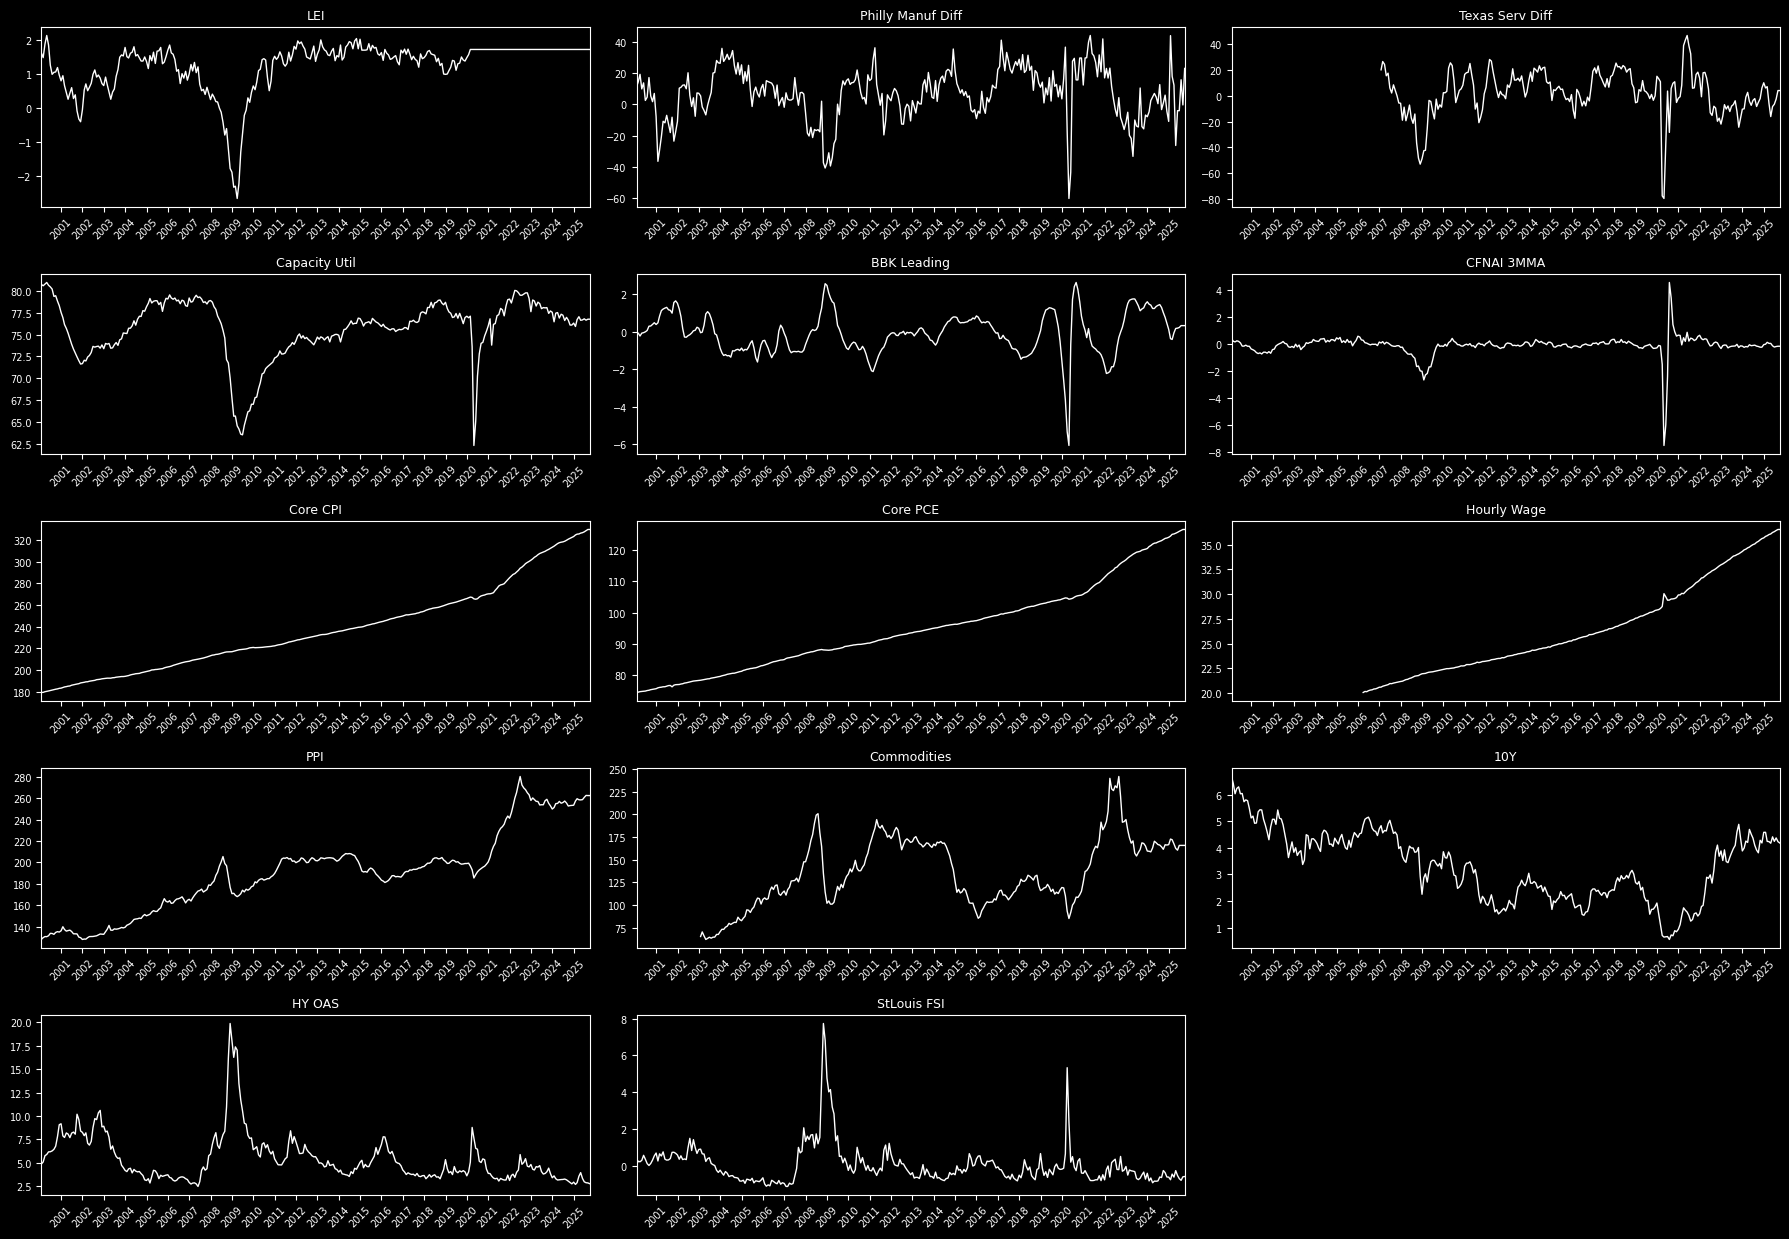

In [4]:
# PLOT ALL SERIES
df_raw = df.copy()

# Determine grid size
n_series = len(df_raw.columns)
ncols    = 3
nrows    = math.ceil(n_series / ncols)

# sharex=False ⇒ each axis shows its own ticks
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols*6, nrows*2.5),
    sharex=False
)

# Flatten axes for easy iteration
axes_flat = axes.flatten()

xmin, xmax = df_raw.index.min(), df_raw.index.max()

for ax, col in zip(axes_flat, df_raw.columns):
    ax.plot(df_raw.index, df_raw[col], lw=1, color='white')
    ax.set_title(col, fontsize=9)
    # enforce same x‐limits on each
    ax.set_xlim(xmin, xmax)
    # format each x‐axis independently
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Turn off any unused subplots
for ax in axes_flat[n_series:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

##### **Data Transformation**

Each series is transformed to focus on changes, not levels.

Year-over-year percent change is used for most variables. Credit spreads and interest rates use 12-month differences, and risk proxies are inverted.

In [5]:
# TRANSFORMS
yoy     = lambda s: s.pct_change(12) * 100
delta12 = lambda s: s.diff(12)
invert  = lambda s: -s

df['LEI']           = yoy(df['LEI'])
df['Capacity Util'] = yoy(df['Capacity Util'])
df['BBK Leading']   = yoy(df['BBK Leading'])

for c in ['Core CPI','Core PCE','Hourly Wage','PPI','Commodities']:
    df[c] = yoy(df[c])

df['10Y']        = invert(delta12(df['10Y']))
df['HY OAS']     = invert(delta12(df['HY OAS']))
df['StLouis FSI']= invert(df['StLouis FSI'])

df.head()

,LEI,Philly Manuf Diff,Texas Serv Diff,Capacity Util,BBK Leading,CFNAI 3MMA,Core CPI,Core PCE,Hourly Wage,PPI,Commodities,10Y,HY OAS,StLouis FSI
DATE,,,,,,,,,,,,,,
2000-01-31,NaN,11.2,NaN,NaN,NaN,0.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0539
2000-02-29,NaN,14.5,NaN,NaN,NaN,0.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.2455
2000-03-31,NaN,19.4,NaN,NaN,NaN,0.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.2122
2000-04-30,NaN,10.0,NaN,NaN,NaN,0.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.2891
2000-05-31,NaN,13.9,NaN,NaN,NaN,0.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.5627


##### **Inflation Composite**

Inflation pressures are captured with the composite of the 5 related series mentioned previously.

In [6]:
# INFLATION COMPOSITE
infl_cols = ['Core CPI','Core PCE','Hourly Wage','PPI','Commodities']
df['Inflation'] = df[infl_cols].mean(axis=1)

# FINAL INPUT LIST
inputs = [
    'LEI','Philly Manuf Diff','Texas Serv Diff',
    'Capacity Util','BBK Leading','CFNAI 3MMA',
    'Inflation','10Y','HY OAS','StLouis FSI'
]

df.head()

,LEI,Philly Manuf Diff,Texas Serv Diff,Capacity Util,BBK Leading,CFNAI 3MMA,Core CPI,Core PCE,Hourly Wage,PPI,Commodities,10Y,HY OAS,StLouis FSI,Inflation
DATE,,,,,,,,,,,,,,,
2000-01-31,NaN,11.2,NaN,NaN,NaN,0.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0539,NaN
2000-02-29,NaN,14.5,NaN,NaN,NaN,0.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.2455,NaN
2000-03-31,NaN,19.4,NaN,NaN,NaN,0.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.2122,NaN
2000-04-30,NaN,10.0,NaN,NaN,NaN,0.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.2891,NaN
2000-05-31,NaN,13.9,NaN,NaN,NaN,0.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.5627,NaN


##### **Z-Score and Final Composite**

All variables are standardized to remove scale effects, then aggregated into the composite score.

Smoothing reduces single-period noise. The slope measures short-term direction.

In [7]:
# Z-SCORES & COMPOSITE
z       = df[inputs].apply(lambda s: (s - s.mean())/s.std())
comp    = z.mean(axis=1)
comp_sm = comp.rolling(SMOOTH_WINDOW, min_periods=1).mean()
slope   = comp.diff(SLOPE_WINDOW)

In [8]:
z

,LEI,Philly Manuf Diff,Texas Serv Diff,Capacity Util,BBK Leading,CFNAI 3MMA,Inflation,10Y,HY OAS,StLouis FSI
DATE,,,,,,,,,,
2000-01-31,NaN,0.253800,NaN,NaN,NaN,0.647433,NaN,NaN,NaN,-0.028513
2000-02-29,NaN,0.450965,NaN,NaN,NaN,0.405680,NaN,NaN,NaN,-0.206202
2000-03-31,NaN,0.743726,NaN,NaN,NaN,0.342061,NaN,NaN,NaN,-0.175320
2000-04-30,NaN,0.182103,NaN,NaN,NaN,0.443852,NaN,NaN,NaN,-0.246637
2000-05-31,NaN,0.415117,NaN,NaN,NaN,0.392956,NaN,NaN,NaN,-0.500372
...,...,...,...,...,...,...,...,...,...,...
2025-05-31,NaN,-0.654357,-0.602117,-0.160906,0.053008,-0.026930,-0.379676,0.039890,-0.089629,0.519207
2025-06-30,NaN,-0.654357,-0.504669,-0.099278,0.053333,-0.141445,-0.219550,0.064142,0.035521,0.675287
2025-07-31,NaN,0.534611,-0.275378,0.017623,0.054366,-0.090549,-0.191724,-0.420903,0.082875,0.760979


##### **Phase Classification**

Each date is classified into a market regime using thresholds on the composite's level and slope.

In [9]:
# PHASE CLASSIFICATION w/ DEAD‐ZONE
comp_thr, slope_thr = 0.15, 0.005
cond_early   = (comp < -comp_thr) & (slope >  slope_thr)
cond_midlate =  comp >  comp_thr
cond_decline = (comp < -comp_thr) & (slope < -slope_thr)
cond_unc     = comp.abs() <= comp_thr

# initial labels as a Series
phase = pd.Series('Mid-Late', index=comp.index)
phase[cond_early]   = 'Early'
phase[cond_decline] = 'Decline'
phase[cond_unc]     = 'Uncertain'

# map to integer codes
code_map = {'Early':0, 'Mid-Late':1, 'Decline':2, 'Uncertain':3}
inv_map  = {v:k for k,v in code_map.items()}
codes = phase.map(code_map)

# apply centered rolling‐mode
min_run = 6
smoothed_codes = codes.rolling(
    window=min_run, center=True, min_periods=1
).apply(
    lambda x: pd.Series(x).value_counts().idxmax(),
    raw=False
)

# back to labels
phase = smoothed_codes.round().astype(int).map(inv_map).values

phase_colors = {
    'Early'     : '#54d62c',
    'Mid-Late'  : '#3fa1ff',
    'Decline'   : '#ff4c4c',
    'Uncertain' : '#ffd400'
}

##### **Retrieve S&P 500 Data for Comparison**

**S&P 500** performance is included in the plot so that we can compare it against the composite indicator and its regimes.

In [10]:
# S&P 500 YoY % via yfinance
data = yf.download('^GSPC',
                   start=START,
                   end=END,
                   auto_adjust=False,
                   progress=False)
# flatten multi-level columns
data.columns = data.columns.get_level_values(0)
spx = data['Adj Close'].resample(FREQ).last().ffill()
spx_yoy = spx.pct_change(12) * 100

data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2000-01-03,1455.219971,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


In [11]:
spx.head()

,Adj Close
Date,
2000-01-31,1394.459961
2000-02-29,1366.420044
2000-03-31,1498.579956
2000-04-30,1452.430054
2000-05-31,1420.599976


In [12]:
spx_yoy.head()

,Adj Close
Date,
2000-01-31,NaN
2000-02-29,NaN
2000-03-31,NaN
2000-04-30,NaN
2000-05-31,NaN


##### **Plot Market-Cycle Composite Indicator**
The final visualization overlays the composite, market regimes, and S&P 500 YoY returns.

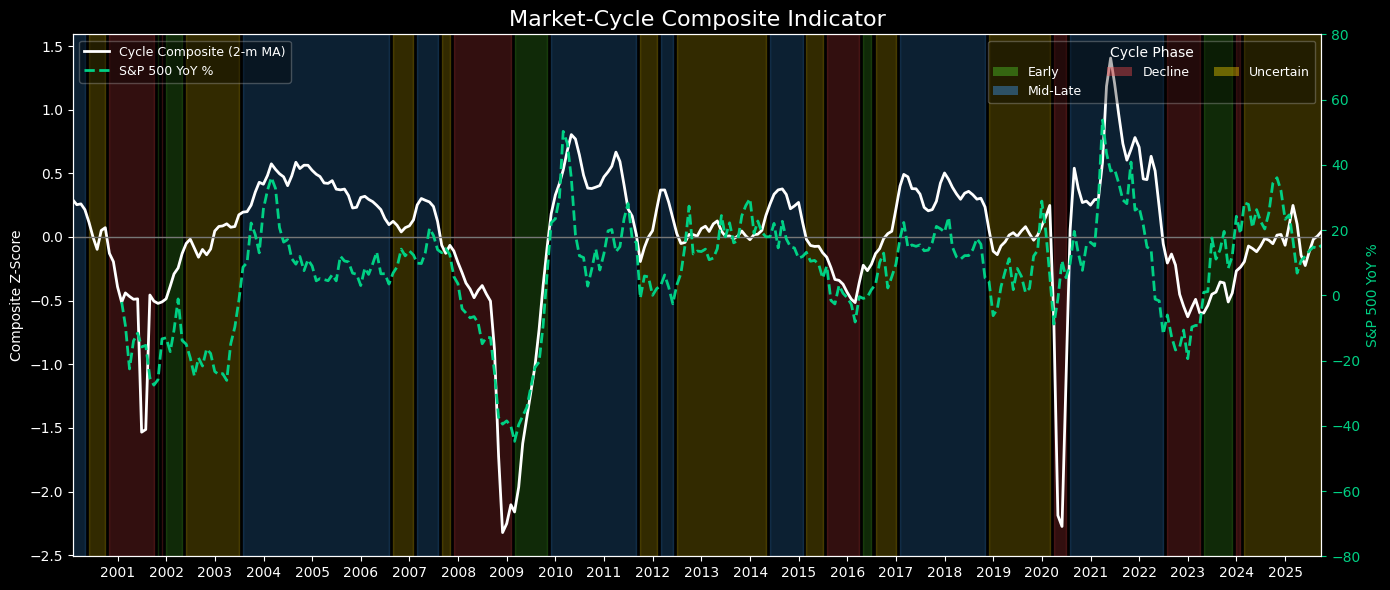

In [13]:
# PLOT
fig, ax = plt.subplots(figsize=(14,6))

mask = pd.Series(phase, index=comp.index)
grp  = (mask != mask.shift()).cumsum()
for ph, col in phase_colors.items():
    for _, span in mask[mask==ph].groupby(grp):
        ax.axvspan(span.index[0], span.index[-1],
                   color=col, alpha=0.20)

ax.plot(comp_sm.index, comp_sm,
        lw=2, color='white',
        label=f'Cycle Composite ({SMOOTH_WINDOW}-m MA)')
ax.axhline(0, color='#777', lw=1)

ax2 = ax.twinx()
ax2.plot(spx_yoy.index, spx_yoy,
         lw=2, ls='--', color='#00d084',
         zorder=5,
         label='S&P 500 YoY %')
ax2.set_ylabel('S&P 500 YoY %', color='#00d084')
ax2.tick_params(axis='y', colors='#00d084')
ax2.set_ylim(-80, 80)

phase_patches = [Patch(facecolor=c, alpha=0.4, label=p)
                 for p, c in phase_colors.items()]
leg1 = ax.legend(handles=phase_patches, title='Cycle Phase',
                 loc='upper right', ncol=3,
                 framealpha=0.3, fontsize=9)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2,
          loc='upper left', framealpha=0.3,
          fontsize=9)
ax.add_artist(leg1)

ax.set_title('Market-Cycle Composite Indicator', fontsize=16)
ax.set_ylabel('Composite Z-Score')
ax.set_xlim(comp.index[0], comp.index[-1])


# major tick: every year
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()